In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
NVIDIA RTX 2000 Ada Generation


In [2]:
#setting the path
from pathlib import Path

PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "plantvillage dataset"
IMAGE_SET = DATA_ROOT / "color"


print("Project root:", PROJECT_ROOT)
print("Data root exists:", DATA_ROOT.exists())
print("Using image set:", IMAGE_SET)
print("Classes:", len([p for p in IMAGE_SET.iterdir() if p.is_dir()]))

Project root: c:\Users\KBE\Desktop\plant-disease-project
Data root exists: True
Using image set: c:\Users\KBE\Desktop\plant-disease-project\data\plantvillage dataset\color
Classes: 38


In [3]:
# store data in a pandas dataframe
import pandas as pd

class_dirs = sorted([p for p in IMAGE_SET.iterdir() if p.is_dir()])

rows = []
for class_dir in class_dirs:
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        for fp in class_dir.glob(ext):
            rows.append({
                "filepath": str(fp),
                "class_name": class_dir.name
            })

df = pd.DataFrame(rows)
class_to_idx = {name: i for i, name in enumerate(sorted(df["class_name"].unique()))}
df["label"] = df["class_name"].map(class_to_idx)
df["image_id"] = df["filepath"].map(lambda x: Path(x).stem)


print(df.columns.tolist())

print("Total images:", len(df))
print("Total classes:", df["class_name"].nunique())
display(df.head())
display(df["class_name"].value_counts().head(10))

['filepath', 'class_name', 'label', 'image_id']
Total images: 54305
Total classes: 38


,filepath,class_name,label,image_id
0,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,00075aa8-d81a-4184-8541-b692b78d398a___FREC_Sc...
1,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Sc...
2,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Sc...
3,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Sc...
4,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,0,023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Sc...


class_name
Orange___Haunglongbing_(Citrus_greening)         5507
Tomato___Tomato_Yellow_Leaf_Curl_Virus           5357
Soybean___healthy                                5090
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Late_blight                             1909
Squash___Powdery_mildew                          1835
Tomato___Septoria_leaf_spot                      1771
Tomato___Spider_mites Two-spotted_spider_mite    1676
Apple___healthy                                  1645
Name: count, dtype: int64

In [4]:
# using phash to calculate perceptual hash of images
import imagehash
from PIL import Image

def calculate_phash(filepath):
    try:
        with Image.open(filepath) as image:
            image = image.convert("RGB")
            return str(imagehash.phash(image))
    except Exception as error:
        print(f"Could not process {filepath}: {error}")
        return None


df["phash"] = df["filepath"].apply(calculate_phash)


df[["filepath", "class_name", "phash"]].head()


,filepath,class_name,phash
0,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,eeb185d21aca690f
1,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,b9e184d31a9c1db5
2,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,96ed92e04b966996
3,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,fcfc005a4b4d7c46
4,c:\Users\KBE\Desktop\plant-disease-project\dat...,Apple___Apple_scab,abfd859095925a9a


In [5]:
# identify duplicate images based on perceptual hash
duplicate_rows = df[
    df.duplicated(subset="phash", keep=False)
].sort_values("phash")
print("Total dataset images:", len(df))
print("Rows belonging to duplicate groups:", len(duplicate_rows))
print("Number of duplicated hash groups:", duplicate_rows["phash"].nunique())

conflicting_groups = (
    df
    .dropna(subset=["phash"])
    .groupby("phash")["class_name"]
    .nunique()
)
conflicting_groups = conflicting_groups[conflicting_groups > 1]
print(
    "Duplicate groups containing different class labels:",
    len(conflicting_groups)
)


Total dataset images: 54305
Rows belonging to duplicate groups: 44
Number of duplicated hash groups: 22
Duplicate groups containing different class labels: 0


In [6]:
df["group_id"] = df["phash"]

duplicate_count = df.duplicated(
    subset=["phash", "class_name"]
).sum()
print("Duplicate rows to remove:", duplicate_count)

# Then drop the duplicates:
before_count = len(df)
df = (
    df
    .drop_duplicates(
        subset=["phash", "class_name"],
        keep="first"
    )
    .reset_index(drop=True)
)
after_count = len(df)
print("Images before duplicate removal:", before_count)
print("Images after duplicate removal:", after_count)
print("Duplicates removed:", before_count - after_count)


Duplicate rows to remove: 22
Images before duplicate removal: 54305
Images after duplicate removal: 54283
Duplicates removed: 22


In [7]:
from sklearn.model_selection import train_test_split

group_df = df[["group_id", "label"]].drop_duplicates()

train_groups, temp_groups = train_test_split(
    group_df,
    test_size=0.30,
    stratify=group_df["label"],
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.50,
    stratify=temp_groups["label"],
    random_state=42
)

train_df = df[df["group_id"].isin(train_groups["group_id"])].reset_index(drop=True)
val_df   = df[df["group_id"].isin(val_groups["group_id"])].reset_index(drop=True)
test_df  = df[df["group_id"].isin(test_groups["group_id"])].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 37998
Val: 8142
Test: 8143


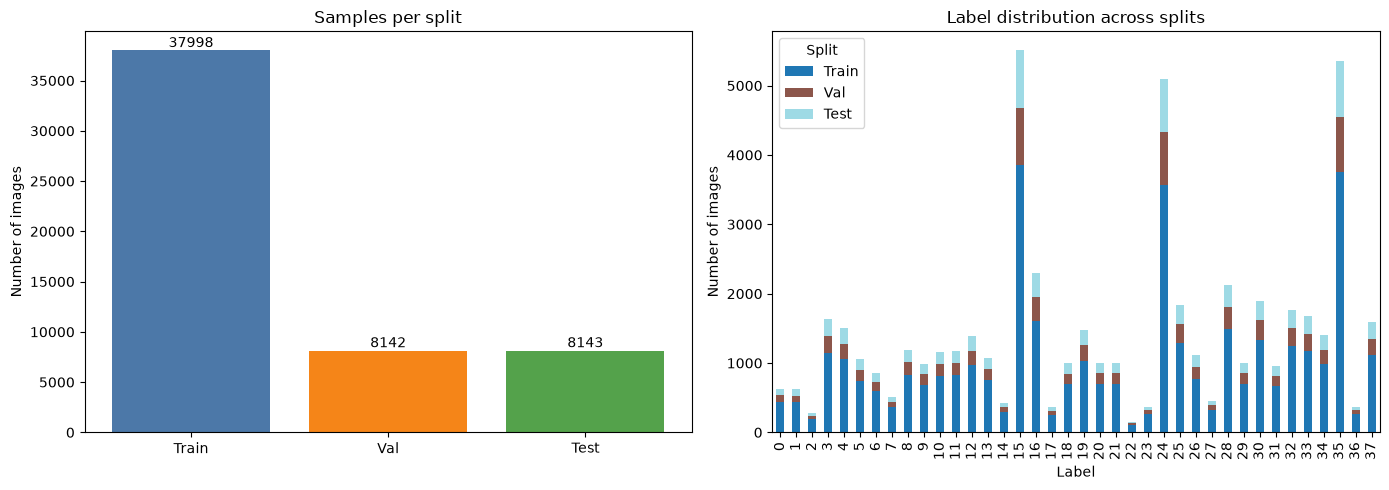

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Split sizes
split_sizes = {
    "Train": len(train_df),
    "Val": len(val_df),
    "Test": len(test_df)
}
axes[0].bar(split_sizes.keys(), split_sizes.values(), color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Samples per split")
axes[0].set_ylabel("Number of images")

for i, v in enumerate(split_sizes.values()):
    axes[0].text(i, v, str(v), ha="center", va="bottom")

# 2) Label distribution per split
dist_df = pd.DataFrame({
    "Train": train_df["label"].value_counts().sort_index(),
    "Val": val_df["label"].value_counts().sort_index(),
    "Test": test_df["label"].value_counts().sort_index()
}).fillna(0)

dist_df.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab20")
axes[1].set_title("Label distribution across splits")
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Number of images")
axes[1].legend(title="Split")

plt.tight_layout()
plt.show()

In [9]:
print("train-val overlap:", len(set(train_df.group_id) & set(val_df.group_id)))
print("train-test overlap:", len(set(train_df.group_id) & set(test_df.group_id)))
print("val-test overlap:", len(set(val_df.group_id) & set(test_df.group_id)))

train-val overlap: 0
train-test overlap: 0
val-test overlap: 0


In [10]:
from tqdm.auto import tqdm
from torchvision import transforms

paths = train_df["filepath"].tolist()


channel_sum = torch.zeros(3)
channel_sum_sq = torch.zeros(3)
pixel_count = 0

for path in tqdm(paths, desc="Computing train mean/std"):
    img = Image.open(path).convert("RGB")
    x = transforms.ToTensor()(img)

    channel_sum += x.sum(dim=(1, 2))
    channel_sum_sq += (x ** 2).sum(dim=(1, 2))
    pixel_count += x.shape[1] * x.shape[2]

mean = channel_sum / pixel_count
std = ((channel_sum_sq / pixel_count) - (mean ** 2)).sqrt()

train_mean = mean.tolist()
train_std = std.tolist()

print("train_mean =", train_mean)
print("train_std  =", train_std)


Computing train mean/std:   0%|          | 0/37998 [00:00<?, ?it/s]

train_mean = [0.4668036699295044, 0.4894063174724579, 0.4109000563621521]
train_std  = [0.19919152557849884, 0.17486873269081116, 0.21735990047454834]


In [11]:
rotation_fill = tuple(int(m * 255) for m in train_mean)
#Basic data augmentation for training images
basic_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10, fill=rotation_fill),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

# Field orientied augmentation for training images
field_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, fill=rotation_fill),
    transforms.ColorJitter( brightness=0.25, contrast=0.20, saturation=0.15, hue=0.02),
    transforms.RandomApply([transforms.GaussianBlur( kernel_size=5, sigma=(0.1, 1.5))], p=0.20),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.15, scale=(0.01, 0.06), ratio=(0.5, 2.0), value="random"),
    transforms.Normalize( mean=train_mean,std=train_std )
])

#validation and test processing transform (no augmentation, just resizing and normalization)
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean, std=train_std),
])

print("Basic training transform created.")
print("Field-oriented training transform created.")
print("Evaluation transform created.")

Basic training transform created.
Field-oriented training transform created.
Evaluation transform created.


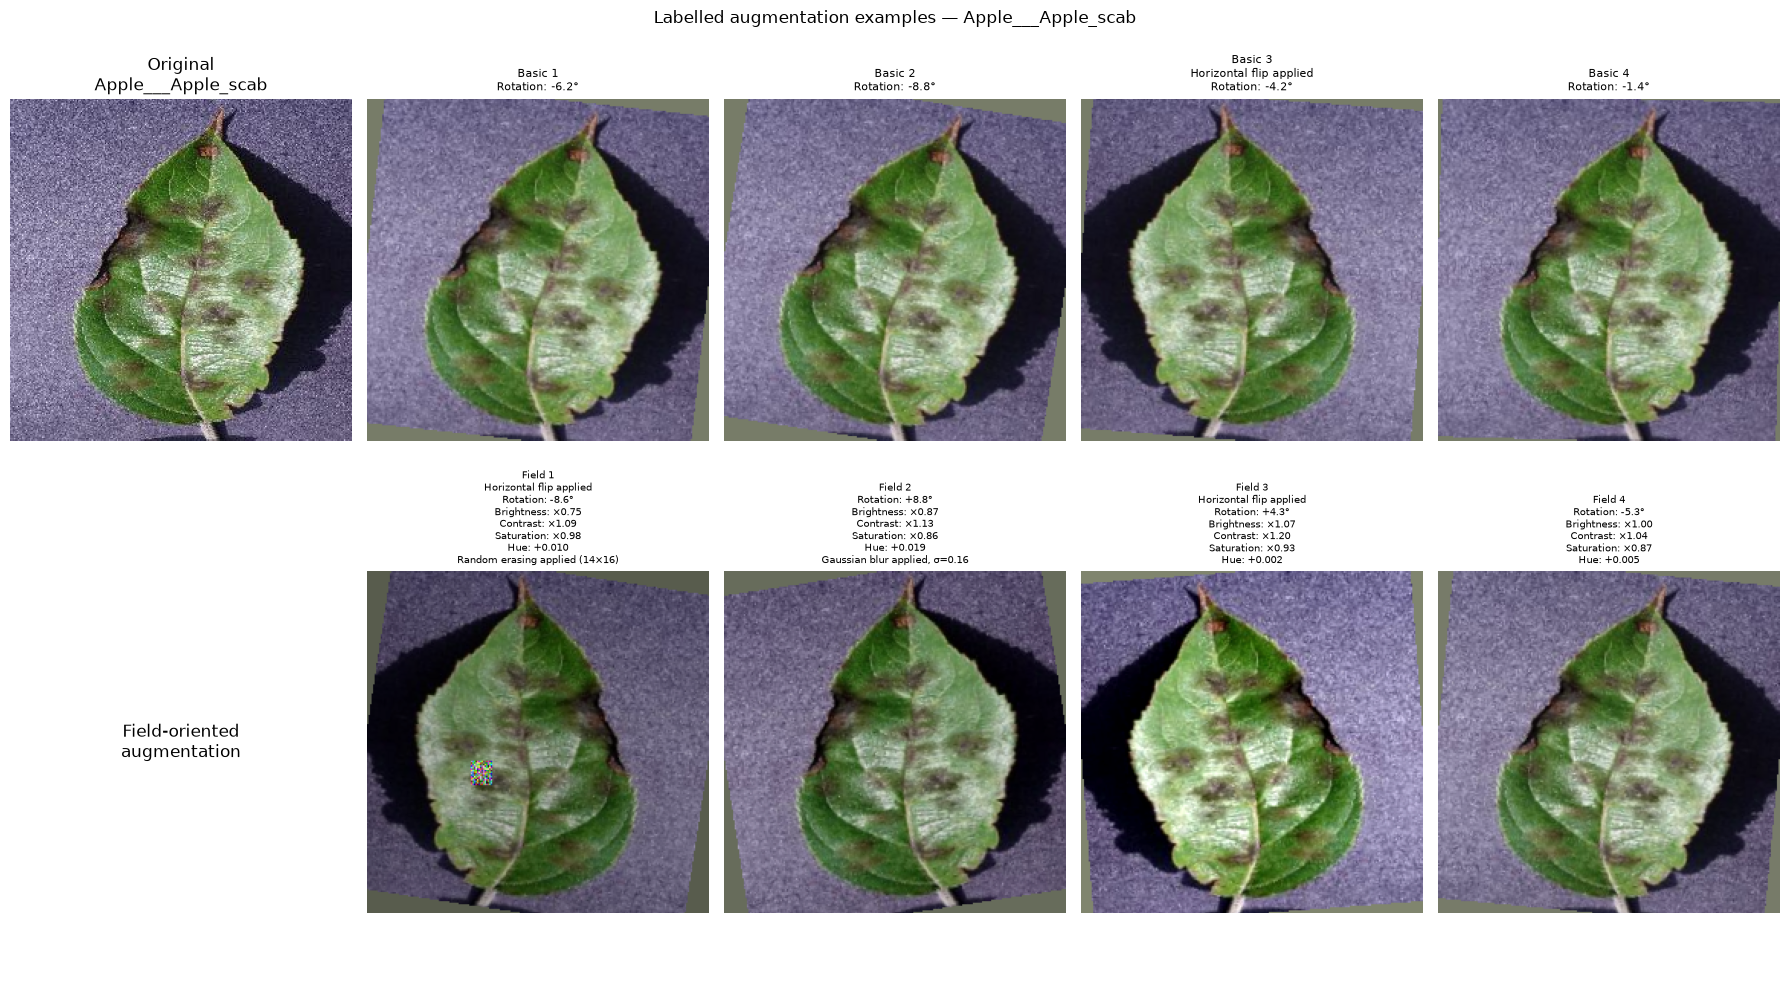

In [12]:
#Visualise augmented samples

import random
import torchvision.transforms.functional as TF
from PIL import Image
from torchvision.transforms import InterpolationMode

def denormalize_image(image_tensor, mean, std):
    image_tensor = image_tensor.clone()
    mean_tensor = torch.tensor(mean, dtype=image_tensor.dtype).view(3, 1, 1)
    std_tensor = torch.tensor(std, dtype=image_tensor.dtype).view(3, 1, 1)
    image_tensor = image_tensor * std_tensor + mean_tensor
    return image_tensor.clamp(0, 1)

def tensor_to_display_image(image_tensor):
    image_tensor = denormalize_image( image_tensor, train_mean, train_std)
    return image_tensor.permute(1, 2, 0).numpy()

def labelled_basic_augmentation(image):
    labels = []
    image = TF.resize(image,[224, 224],interpolation=InterpolationMode.BILINEAR)
    if random.random() < 0.5:
        image = TF.hflip(image)
        labels.append("Horizontal flip applied")
    angle = random.uniform(-10, 10)
    image = TF.rotate(image, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=rotation_fill)
    labels.append(f"Rotation: {angle:+.1f}°")
    image = TF.to_tensor(image)
    image = TF.normalize(image, mean=train_mean, std=train_std)
    return image, labels

def labelled_field_augmentation(image):
    labels = []
    image = TF.resize(image, [224, 224], interpolation=InterpolationMode.BILINEAR)
    if random.random() < 0.5:
        image = TF.hflip(image)
        labels.append("Horizontal flip applied")

    angle = random.uniform(-10, 10)
    image = TF.rotate(image, angle=angle, interpolation=InterpolationMode.BILINEAR, fill=rotation_fill)
    labels.append(f"Rotation: {angle:+.1f}°")

    brightness = random.uniform(0.75, 1.25)
    image = TF.adjust_brightness(image, brightness)
    labels.append(f"Brightness: ×{brightness:.2f}")

    contrast = random.uniform(0.80, 1.20)
    image = TF.adjust_contrast(image, contrast)
    labels.append(f"Contrast: ×{contrast:.2f}")

    saturation = random.uniform(0.85, 1.15)
    image = TF.adjust_saturation(image, saturation)
    labels.append(f"Saturation: ×{saturation:.2f}")

    hue = random.uniform(-0.02, 0.02)
    image = TF.adjust_hue(image, hue)
    labels.append(f"Hue: {hue:+.3f}")

    if random.random() < 0.20:
        sigma = random.uniform(0.1, 1.5)
        image = TF.gaussian_blur(image, kernel_size=[5, 5], sigma=[sigma, sigma])
        labels.append(f"Gaussian blur applied, σ={sigma:.2f}")

    image = TF.to_tensor(image)

    if random.random() < 0.15:
        _, height, width = image.shape
        erase_height = random.randint(12, 25)
        erase_width = random.randint(12, 25)
        top = random.randint(0, height - erase_height)
        left = random.randint(0, width - erase_width)
        image[:, top:top + erase_height, left:left + erase_width] = torch.rand(3, erase_height, erase_width)
        labels.append(f"Random erasing applied ({erase_width}×{erase_height})")

    image = TF.normalize(image, mean=train_mean, std=train_std)

    return image, labels

sample_row = train_df.sample(n=1,random_state=42).iloc[0]
sample_path = sample_row["filepath"]
sample_class = sample_row["class_name"]

with Image.open(sample_path) as image:
    original_image = image.convert("RGB")

fig, axes = plt.subplots(2, 5, figsize=(18, 10))

axes[0, 0].imshow(original_image)
axes[0, 0].set_title(f"Original\n{sample_class}")
axes[0, 0].axis("off")

for column in range(1, 5):
    image_tensor, labels = labelled_basic_augmentation(original_image.copy())
    axes[0, column].imshow( tensor_to_display_image(image_tensor))
    axes[0, column].set_title(f"Basic {column}\n" + "\n".join(labels), fontsize=8)
    axes[0, column].axis("off")

axes[1, 0].text(0.5, 0.5, "Field-oriented\naugmentation", ha="center", va="center", fontsize=12)
axes[1, 0].axis("off")

for column in range(1, 5):
    image_tensor, labels = labelled_field_augmentation(original_image.copy())
    axes[1, column].imshow(tensor_to_display_image(image_tensor))
    axes[1, column].set_title(f"Field {column}\n" + "\n".join(labels), fontsize=7)
    axes[1, column].axis("off")

plt.suptitle(f"Labelled augmentation examples — {sample_class}")
plt.tight_layout()
plt.show()

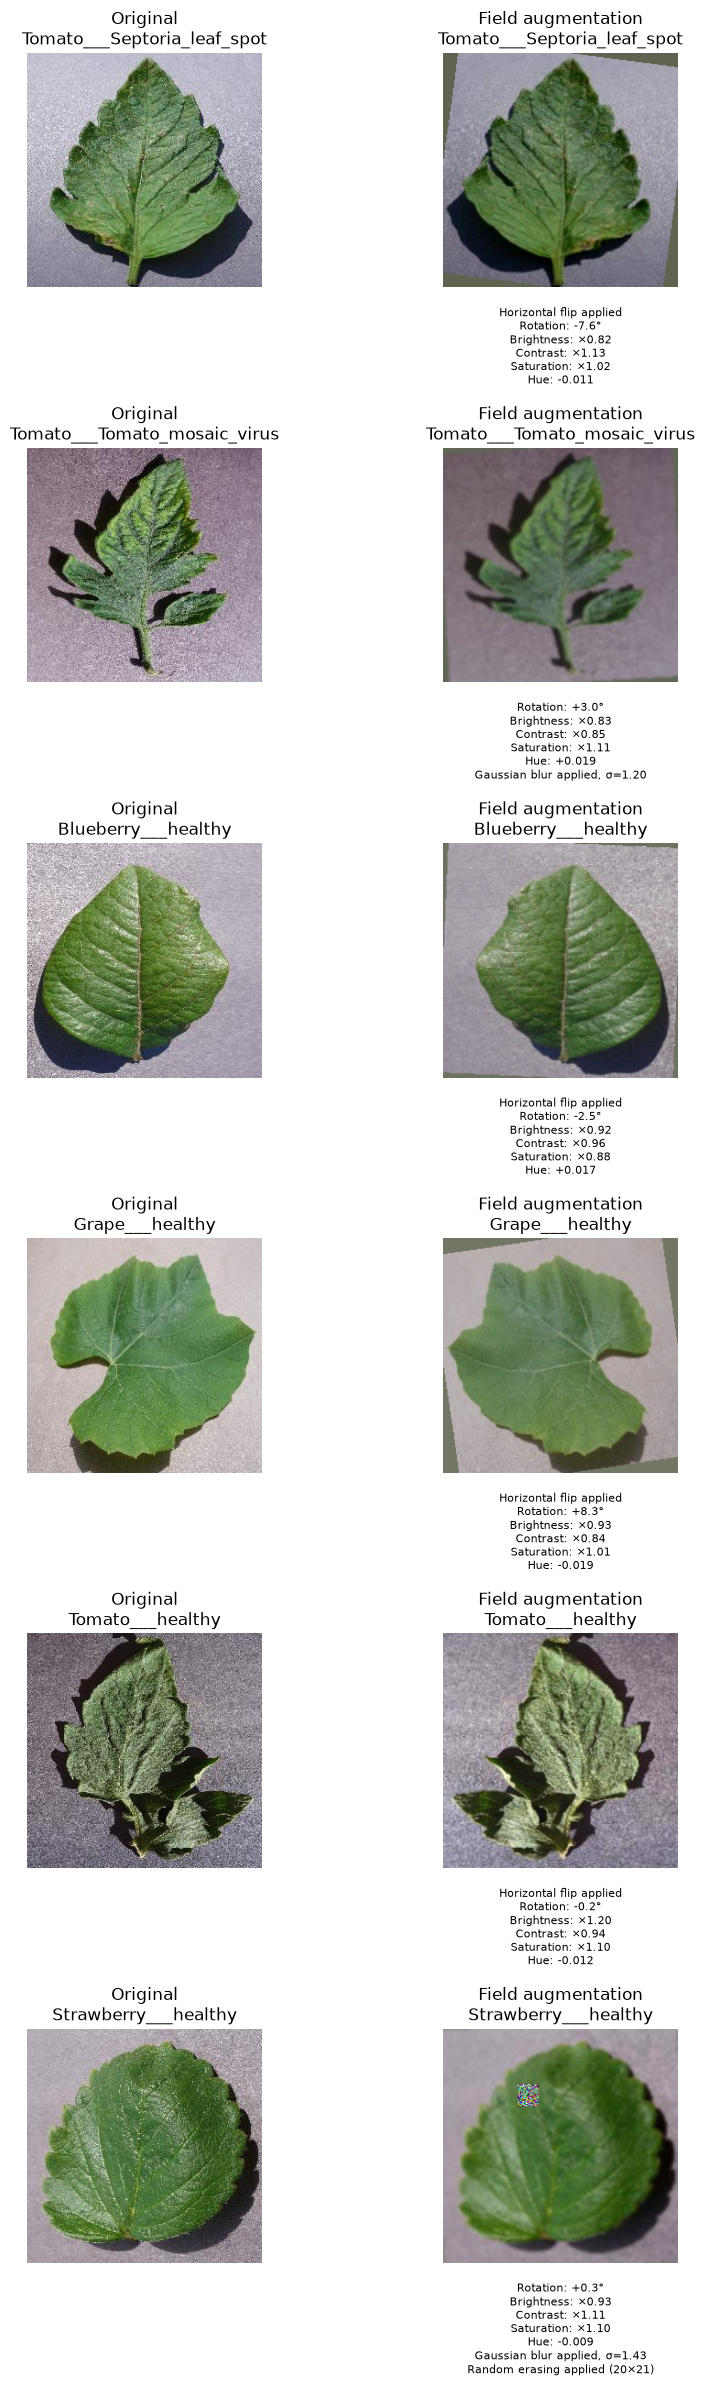

In [13]:
# Select six different classes.
selected_classes = (train_df["class_name"].drop_duplicates().sample(n=min(6, train_df["class_name"].nunique()),random_state=42).tolist())

fig, axes = plt.subplots( nrows=len(selected_classes), ncols=2, figsize=(9, 4 * len(selected_classes)))

# Handle the case where only one class is selected.
if len(selected_classes) == 1:
    axes = [axes]

for row_index, class_name in enumerate(selected_classes):
    # Select one image from the current class.
    class_sample = train_df[train_df["class_name"] == class_name].sample(n=1,random_state=42).iloc[0]
    image_path = class_sample["filepath"]
    with Image.open(image_path) as image:
        original = image.convert("RGB")

    # Create one field-oriented augmented version.
    #augmented_tensor = field_train_transform(original)
    augmented_tensor,labels = labelled_field_augmentation(original)
    augmented = tensor_to_display_image(augmented_tensor)

    # Original image.
    axes[row_index][0].imshow(original)
    axes[row_index][0].set_title(f"Original\n{class_name}")
    axes[row_index][0].axis("off")

    # Augmented image.
    axes[row_index][1].imshow(augmented)
    axes[row_index][1].set_title(f"Field augmentation\n{class_name}")
    axes[row_index][1].axis("off")
    axes[row_index][1].text(0.5, -0.08,"\n".join(labels), transform=axes[row_index][1].transAxes, ha="center", va="top", fontsize=8)


# convert this to landscape orientation for better viewing
plt.tight_layout()
plt.show()

Number of classes : 38
Majority class    : Orange___Haunglongbing_(Citrus_greening)
Accuracy          : 0.101
Macro-F1          : 0.005


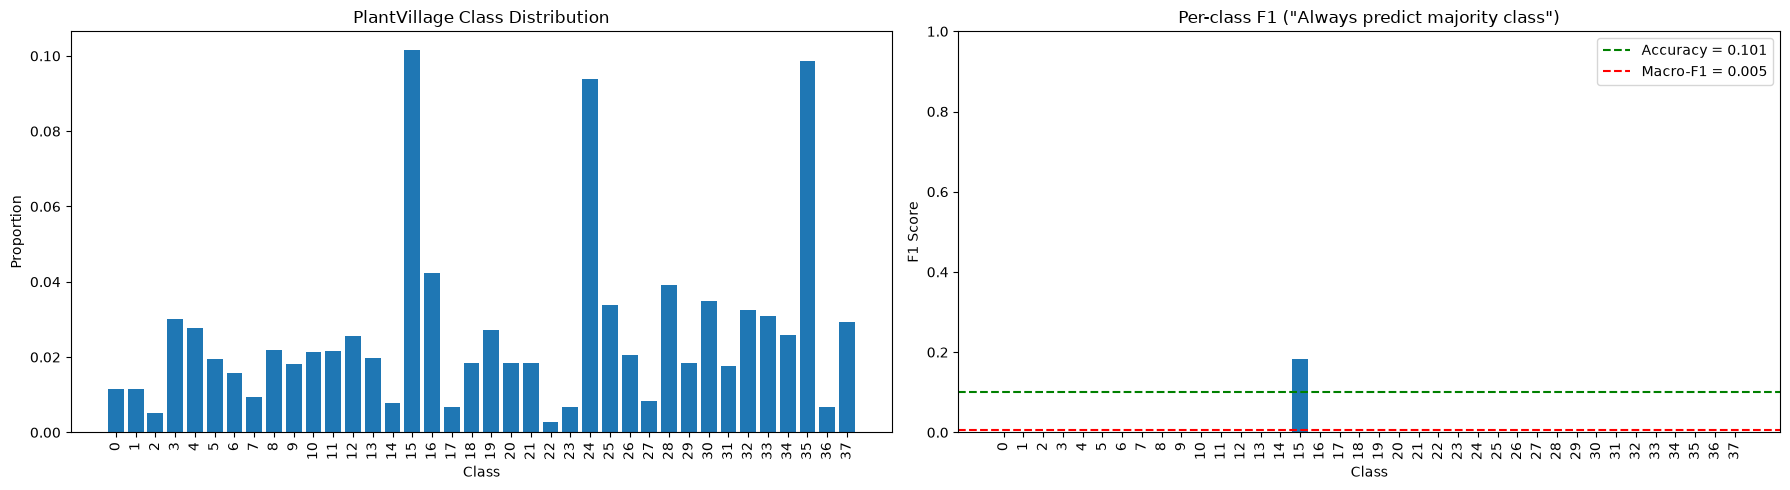

In [14]:
# 6 · Class imbalance & why macro-F1 is used

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Encode class names as integers
encoder = LabelEncoder()
y_true = encoder.fit_transform(df["class_name"])

# Number of classes
num_classes = len(encoder.classes_)

# Majority class
majority_class = np.bincount(y_true).argmax()

# Lazy classifier: predicts only the majority class
y_pred_lazy = np.full_like(y_true, majority_class)

# Metrics
accuracy = accuracy_score(y_true, y_pred_lazy)

macro_f1 = f1_score(
    y_true,
    y_pred_lazy,
    average="macro",
    zero_division=0
)

per_class_f1 = f1_score(
    y_true,
    y_pred_lazy,
    labels=range(num_classes),
    average=None,
    zero_division=0
)

# Actual class distribution
class_counts = df["class_name"].value_counts().sort_index()
class_distribution = class_counts / class_counts.sum()

print(f"Number of classes : {num_classes}")
print(f"Majority class    : {encoder.classes_[majority_class]}")
print(f"Accuracy          : {accuracy:.3f}")
print(f"Macro-F1          : {macro_f1:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Class distribution
axes[0].bar(range(num_classes), class_distribution)
axes[0].set_title("PlantVillage Class Distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Proportion")
axes[0].set_xticks(range(num_classes))
axes[0].tick_params(axis="x", rotation=90)

# Per-class F1
axes[1].bar(range(num_classes), per_class_f1)

axes[1].axhline(
    accuracy,
    linestyle="--",
    color="green",
    label=f"Accuracy = {accuracy:.3f}"
)

axes[1].axhline(
    macro_f1,
    linestyle="--",
    color="red",
    label=f"Macro-F1 = {macro_f1:.3f}"
)

axes[1].set_title('Per-class F1 ("Always predict majority class")')
axes[1].set_xlabel("Class")
axes[1].set_ylabel("F1 Score")
axes[1].set_xticks(range(num_classes))
axes[1].tick_params(axis="x", rotation=90)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

Full train set: 37998
Prototyping subset: 18999 (50%)


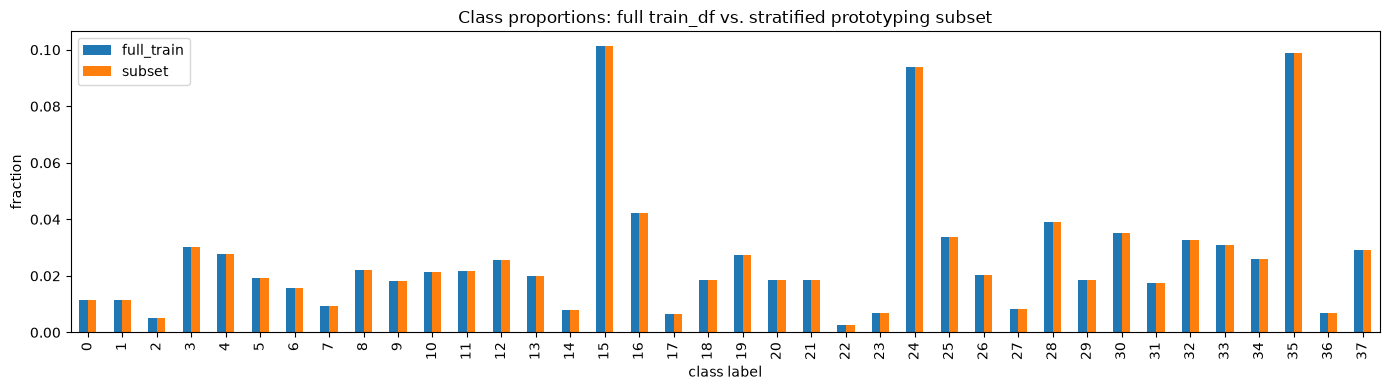

In [16]:
# 7 · Stratified subset of train_df for fast pipeline prototyping
# (train_df itself is left untouched for later use in the full-scale run
# and the Stage-4 data-efficiency curve: 10k / 20k / 30k / all)
from sklearn.model_selection import train_test_split

SUBSET_FRACTION_15 = 0.15  # ~15% of train_df, used only for fast pipeline sanity-checks
SUBSET_FRACTION_30 = 0.30  # ~30% of train_df, used only for fast pipeline sanity-checks
SUBSET_FRACTION_50 = 0.50  # ~50% of train_df, used only for fast pipeline sanity-checks

train_subset_df, _ = train_test_split(
    train_df,
    train_size=SUBSET_FRACTION_50,
    stratify=train_df["label"],
    random_state=42,
)
train_subset_df = train_subset_df.reset_index(drop=True) 

print("Full train set:", len(train_df))
print("Prototyping subset:", len(train_subset_df), f"({SUBSET_FRACTION_50:.0%})")

# Confirm the subset preserved class proportions
full_prop = train_df["label"].value_counts(normalize=True).sort_index()
subset_prop = train_subset_df["label"].value_counts(normalize=True).sort_index()

prop_compare = pd.DataFrame({"full_train": full_prop, "subset": subset_prop})
prop_compare.plot(kind="bar", figsize=(14, 4))
plt.title("Class proportions: full train_df vs. stratified prototyping subset")
plt.ylabel("fraction")
plt.xlabel("class label")
plt.tight_layout()
plt.show()

Class weights (inverse frequency), computed from train_subset_df:


label
0     2.262324
1     2.293457
2     5.208059
3     0.872554
4     0.952331
5     1.358624
6     1.672153
7     2.793149
8     1.198978
9     1.449199
10    1.228437
11    1.210590
12    1.033003
13    1.329717
14    3.378201
15    0.259457
16    0.621858
17    3.968045
18    1.432589
19    0.965200
20    1.428496
21    1.428496
22    9.433466
23    3.845951
24    0.280569
25    0.778775
26    1.288592
27    3.144489
28    0.672008
29    1.428496
30    0.750711
31    1.501422
32    0.806409
33    0.851744
34    1.016207
35    0.266653
36    3.816593
37    0.902480
Name: count, dtype: float64

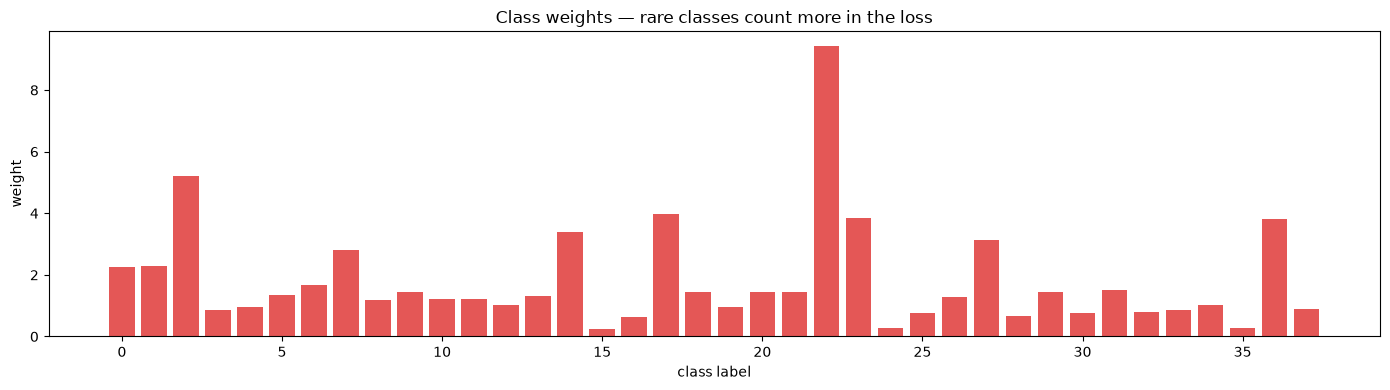

In [17]:
# 8 · Class weights (inverse frequency) from train_subset_df only
# Ready to plug into nn.CrossEntropyLoss(weight=class_weights) in the training loop step
import numpy as np

num_classes = df["label"].nunique()

class_counts = (
    train_subset_df["label"]
    .value_counts()
    .reindex(range(num_classes), fill_value=0)
    .sort_index()
)

missing_classes = class_counts[class_counts == 0]
if len(missing_classes):
    print(
        "Warning: classes missing from the prototyping subset "
        f"(weight set to 0): {missing_classes.index.tolist()}"
    )

safe_counts = class_counts.replace(0, np.nan)
class_weights_arr = (safe_counts.sum() / (num_classes * safe_counts)).fillna(0.0)
class_weights = torch.tensor(class_weights_arr.values, dtype=torch.float32, device=device)

print("Class weights (inverse frequency), computed from train_subset_df:")
display(class_weights_arr)

plt.figure(figsize=(14, 4))
plt.bar(range(num_classes), class_weights_arr.values, color="#E45756")
plt.title("Class weights — rare classes count more in the loss")
plt.xlabel("class label")
plt.ylabel("weight")
plt.tight_layout()
plt.show()

In [18]:
# 9 · Custom Dataset wiring filepaths + transforms together
from torch.utils.data import Dataset


class PlantVillageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.filepaths = dataframe["filepath"].tolist()
        self.labels = dataframe["label"].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        image = Image.open(self.filepaths[idx]).convert("RGB")
        image = self.transform(image)
        label = self.labels[idx]
        return image, label


print("PlantVillageDataset defined.")

PlantVillageDataset defined.


In [19]:
# 10 · Build train / val / test DataLoaders
# train uses field_train_transform (augmented, on the fly, each epoch);
# val/test use eval_transform only (no augmentation).
# test_loader is built for later use but is NOT touched until final evaluation (Stage 5).
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataset = PlantVillageDataset(train_subset_df, field_train_transform)
val_dataset = PlantVillageDataset(val_df, eval_transform)
test_dataset = PlantVillageDataset(test_df, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("train_dataset:", len(train_dataset))
print("val_dataset:  ", len(val_dataset))
print("test_dataset: ", len(test_dataset), "(held out, not evaluated yet)")

# Sanity-check one batch
xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape)
print("Batch label range:", yb.min().item(), "-", yb.max().item())

train_dataset: 18999
val_dataset:   8142
test_dataset:  8143 (held out, not evaluated yet)
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label range: 0 - 35


In [20]:
# 11 · Baseline model: SimpleCNN
# A compact 4-block conv net, no pretraining, no residual connections.
# This is the deliberate starting point (proposal Sec. 4.2): train this first so that
# later, when ResNet-50 is added, we can MEASURE what the pretrained model actually
# bought us instead of assuming it.
import torch.nn as nn


class SimpleCNN(nn.Module):
    def __init__(self, n_classes, w=32):
        super().__init__()
        block = lambda i, o: nn.Sequential(
            nn.Conv2d(i, o, 3, padding=1),
            nn.BatchNorm2d(o),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.features = nn.Sequential(
            block(3, w), block(w, 2 * w), block(2 * w, 4 * w), block(4 * w, 4 * w)
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(4 * w, n_classes)
        )

    def forward(self, x):
        return self.head(self.features(x))


NUM_CLASSES = df["label"].nunique()
print(
    "SimpleCNN parameters:",
    f"{sum(p.numel() for p in SimpleCNN(NUM_CLASSES).parameters()):,}",
)

# Sanity check: a correctly-wired pipeline can memorise ONE batch (loss -> ~0)
xb, yb = next(iter(train_loader))
model = SimpleCNN(NUM_CLASSES).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
for _ in range(100):
    loss = crit(model(xb.to(device)), yb.to(device))
    opt.zero_grad()
    loss.backward()
    opt.step()
print(f"single-batch loss after 100 steps: {loss.item():.4f}  (near 0 => the wiring works)")

SimpleCNN parameters: 246,438
single-batch loss after 100 steps: 0.0237  (near 0 => the wiring works)


In [21]:
# 12 · run_epoch_with_macroF1(): one full pass over a loader (train or eval)
# Generic and model-agnostic -- reused for every training run (SimpleCNN now,
# ResNet-50 later, prototyping subset now, full train_df later).

def run_epoch_with_macroF1(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_targets = []
    all_predictions = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        correct_predictions += (
            predictions == labels
        ).sum().item()
        total_samples += batch_size

        # Store labels and predictions for macro-F1
        all_targets.extend(
            labels.detach().cpu().numpy()
        )

        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = total_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    epoch_macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        labels=range(NUM_CLASSES),
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_macro_f1


In [22]:
# 13 · train_model(): runs the full training loop over multiple epochs
# Reusable across runs -- pass in whichever model/loaders/loss/optimizer you want
# (prototyping subset now, full train_df later, SimpleCNN now, ResNet-50 later).
def train_model(model, train_loader, val_loader, crit, opt, epochs, patience=5):
    hist = {k: [] for k in ["tr_loss", "tr_acc", "tr_macro_f1", "va_loss", "va_acc", "va_macro_f1"]}
    best_val_macro_f1 = -1.0
    best_epoch = -1
    best_state = None
    wait = 0

    for ep in range(epochs):
        tl, ta, tm = run_epoch_with_macroF1(model, train_loader, crit, opt)  # TRAIN pass (weights update)
        vl, va, vm = run_epoch_with_macroF1(model, val_loader, crit)  # VAL pass (no update)
        for k, v in zip(hist, [tl, ta, tm, vl, va, vm]):
            hist[k].append(v)

        if vm > best_val_macro_f1:
          best_val_macro_f1 = vm
          best_epoch = ep + 1
          best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
          wait = 0
        else:
          wait += 1

        print(
            f"epoch {ep + 1:2d}/{epochs} | train loss {tl:.3f} acc {ta:.3f} macro-F1 {tm:.3f} "
            f"| val loss {vl:.3f} acc {va:.3f} macro-F1 {vm:.3f}"
        )
        if wait >= patience:
          print(
              f"Early stopping at epoch {ep + 1}. "
              f"Best epoch: {best_epoch} (val macro-F1={best_val_macro_f1:.3f})"
          )
          break
    return hist, best_epoch, best_state, best_val_macro_f1


print("train_model() defined.")

train_model() defined.


In [23]:
# 14 · plot_history(): loss/accuracy curves, reusable for every run
def plot_history(hist, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
    ax[0].plot(hist["tr_loss"], "o-", label="train")
    ax[0].plot(hist["va_loss"], "o-", label="val")
    ax[0].set_title("Loss per epoch")
    ax[0].set_xlabel("epoch")
    ax[0].legend()

    ax[1].plot(hist["tr_acc"], "o-", label="train")
    ax[1].plot(hist["va_acc"], "o-", label="val")
    ax[1].set_title("Accuracy per epoch")
    ax[1].set_xlabel("epoch")
    ax[1].legend()

    ax[2].plot(hist["tr_macro_f1"], "o-", label="train")
    ax[2].plot(hist["va_macro_f1"], "o-", label="val")
    ax[2].set_title("Macro-F1 per epoch")
    ax[2].set_xlabel("epoch")
    ax[2].legend()

    suptitle = "What to watch: loss goes DOWN, accuracy goes UP. A big train–val gap = overfitting."
    if title:
        suptitle = f"{title}\n{suptitle}"
    plt.suptitle(suptitle, y=1.05)
    plt.tight_layout()
    plt.show()


print("plot_history() defined.")

plot_history() defined.


epoch  1/40 | train loss 2.240 acc 0.446 macro-F1 0.362 | val loss 1.279 acc 0.662 macro-F1 0.593
epoch  2/40 | train loss 1.300 acc 0.636 macro-F1 0.574 | val loss 0.929 acc 0.729 macro-F1 0.683
epoch  3/40 | train loss 0.968 acc 0.720 macro-F1 0.666 | val loss 0.758 acc 0.783 macro-F1 0.750
epoch  4/40 | train loss 0.780 acc 0.768 macro-F1 0.723 | val loss 0.453 acc 0.878 macro-F1 0.848
epoch  5/40 | train loss 0.647 acc 0.804 macro-F1 0.763 | val loss 0.440 acc 0.875 macro-F1 0.840
epoch  6/40 | train loss 0.570 acc 0.827 macro-F1 0.787 | val loss 0.347 acc 0.901 macro-F1 0.877
epoch  7/40 | train loss 0.483 acc 0.852 macro-F1 0.820 | val loss 0.379 acc 0.882 macro-F1 0.847
epoch  8/40 | train loss 0.437 acc 0.862 macro-F1 0.830 | val loss 0.359 acc 0.885 macro-F1 0.851
epoch  9/40 | train loss 0.412 acc 0.870 macro-F1 0.841 | val loss 0.320 acc 0.902 macro-F1 0.881
epoch 10/40 | train loss 0.362 acc 0.884 macro-F1 0.857 | val loss 0.308 acc 0.906 macro-F1 0.881
epoch 11/40 | train 

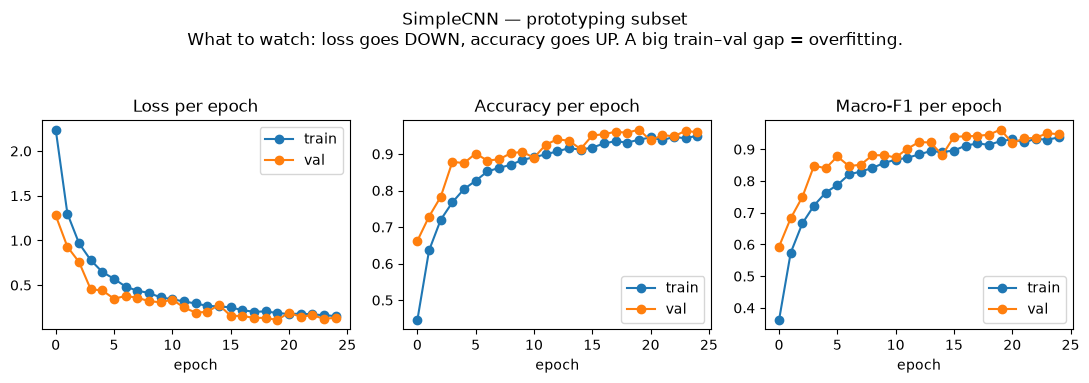

In [26]:
# Purpose: confirm the whole pipeline trains sanely end-to-end before scaling up
# to the full train_df (or swapping in ResNet-50). Not the final reported result.
import time

total_training_start = time.time()

model = SimpleCNN(NUM_CLASSES).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss(weight=class_weights)

EPOCHS = 40
PATIENCE = 5


hist, best_epoch, best_state, best_val_macro_f1 = train_model(model, train_loader, val_loader, crit, opt, epochs=EPOCHS, patience=PATIENCE)

model.load_state_dict(best_state)

test_loss, test_acc, test_macro_f1 = run_epoch_with_macroF1(model, test_loader, crit)
print(f"Final TEST | loss {test_loss:.3f} acc {test_acc:.3f} macro-F1 {test_macro_f1:.3f}")

total_training_seconds = time.time() - total_training_start

total_hours = int(total_training_seconds // 3600)
total_minutes = int((total_training_seconds % 3600) // 60)
total_seconds = total_training_seconds % 60

print(f"Best epoch: {best_epoch}")
print(f"Best val macro-F1: {best_val_macro_f1:.3f}")
print(
    f"Total training time: {total_hours}h {total_minutes}m {total_seconds:.1f}s "
    f"({total_training_seconds:.1f} seconds)"
)

plot_history(hist, title="SimpleCNN — prototyping subset")


In [27]:
# ResNet-50 (or ResNet-18) with pretrained ImageNet weights
from torchvision import models, transforms

def build_model(backbone="resnet50", n_classes=NUM_CLASSES, pretrained=True, freeze_backbone=True, dropout=0.3):
    """
    Build a ResNet model for PlantVillage classification.
    backbone:'resnet18' or 'resnet50'
    pretrained:Load ImageNet weights when True.
    freeze_backbone: Freeze the pretrained feature extractor during Phase 1.
    dropout: Dropout used in the new classification head.
    """

    constructors = {"resnet18": models.resnet18,"resnet50": models.resnet50}
    weight_options = {"resnet18": models.ResNet18_Weights.DEFAULT,"resnet50": models.ResNet50_Weights.DEFAULT}

    if backbone not in constructors:
        raise ValueError(
            "backbone must be 'resnet18' or 'resnet50'"
        )

    constructor = constructors[backbone]
    weights = weight_options[backbone] if pretrained else None

    try:
        model = constructor(weights=weights)

    except Exception as error:
        print(
            f"Pretrained weights unavailable "
            f"({type(error).__name__}). Using random weights."
        )

        model = constructor(weights=None)

    # Freeze the original ResNet backbone
    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False

    # Replace the original 1000-class ImageNet classifier
    input_features = model.fc.in_features
    model.fc = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(input_features, n_classes))
    return model


print(
    "build_model() ready. "
    "Use backbone='resnet18' or backbone='resnet50'."
)

build_model() ready. Use backbone='resnet18' or backbone='resnet50'.


In [28]:
#parameter_counts(): count total and trainable parameters in a model
def parameter_counts(model):
    total_parameters = sum(parameter.numel() for parameter in model.parameters())
    trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total_parameters, trainable_parameters


simple_cnn_comparison = SimpleCNN(NUM_CLASSES)
resnet18_frozen = build_model(backbone="resnet18", pretrained=False, freeze_backbone=True)
resnet50_frozen = build_model(backbone="resnet50", pretrained=False, freeze_backbone=True)


# Verify the ResNet-50 output shape
dummy_input = torch.randn(4, 3, 224, 224)

with torch.no_grad():
    dummy_output = resnet50_frozen(dummy_input)

print(
    "ResNet-50 output shape:",
    tuple(dummy_output.shape),
    f"(expected: (4, {NUM_CLASSES}))"
)


for model_name, current_model in [
    ("SimpleCNN", simple_cnn_comparison),
    ("ResNet-18 frozen", resnet18_frozen),
    ("ResNet-50 frozen", resnet50_frozen)
]:
    total, trainable = parameter_counts(current_model)

    print(
        f"{model_name:22s} | "
        f"Total: {total:12,d} | "
        f"Trainable: {trainable:10,d} | "
        f"Trainable percentage: "
        f"{100 * trainable / total:5.2f}%"
    )

ResNet-50 output shape: (4, 38) (expected: (4, 38))
SimpleCNN              | Total:      246,438 | Trainable:    246,438 | Trainable percentage: 100.00%
ResNet-18 frozen       | Total:   11,196,006 | Trainable:     19,494 | Trainable percentage:  0.17%
ResNet-50 frozen       | Total:   23,585,894 | Trainable:     77,862 | Trainable percentage:  0.33%


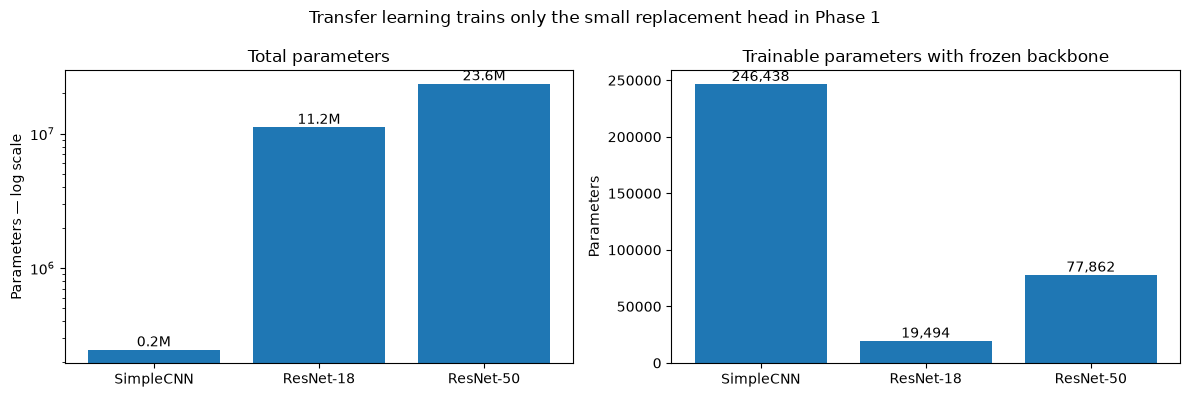

In [29]:
model_names = ["SimpleCNN","ResNet-18","ResNet-50"]
comparison_models = [simple_cnn_comparison,resnet18_frozen,resnet50_frozen]
total_parameters = [parameter_counts(model)[0] for model in comparison_models]
trainable_parameters = [parameter_counts(model)[1] for model in comparison_models]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(model_names,total_parameters)
axes[0].set_yscale("log")
axes[0].set_title("Total parameters")
axes[0].set_ylabel("Parameters — log scale")

for index, value in enumerate(total_parameters):
    axes[0].text(index, value, f"{value / 1e6:.1f}M", ha="center", va="bottom")

axes[1].bar( model_names, trainable_parameters)
axes[1].set_title("Trainable parameters with frozen backbone")
axes[1].set_ylabel("Parameters")

for index, value in enumerate(trainable_parameters):
    axes[1].text(index, value, f"{value:,}", ha="center", va="bottom")

plt.suptitle("Transfer learning trains only the small replacement head in Phase 1")
plt.tight_layout()
plt.show()

epoch  1/10 | train loss 1.528 acc 0.763 macro-F1 0.702 | val loss 0.665 acc 0.894 macro-F1 0.864
epoch  2/10 | train loss 0.639 acc 0.877 macro-F1 0.847 | val loss 0.395 acc 0.916 macro-F1 0.892
epoch  3/10 | train loss 0.475 acc 0.896 macro-F1 0.870 | val loss 0.305 acc 0.929 macro-F1 0.912
epoch  4/10 | train loss 0.395 acc 0.908 macro-F1 0.889 | val loss 0.270 acc 0.935 macro-F1 0.914
epoch  5/10 | train loss 0.340 acc 0.912 macro-F1 0.892 | val loss 0.224 acc 0.947 macro-F1 0.933
epoch  6/10 | train loss 0.307 acc 0.921 macro-F1 0.905 | val loss 0.246 acc 0.937 macro-F1 0.917
epoch  7/10 | train loss 0.290 acc 0.921 macro-F1 0.901 | val loss 0.190 acc 0.952 macro-F1 0.938
epoch  8/10 | train loss 0.269 acc 0.928 macro-F1 0.912 | val loss 0.182 acc 0.953 macro-F1 0.939
epoch  9/10 | train loss 0.255 acc 0.930 macro-F1 0.914 | val loss 0.166 acc 0.956 macro-F1 0.946
epoch 10/10 | train loss 0.247 acc 0.930 macro-F1 0.913 | val loss 0.167 acc 0.952 macro-F1 0.943
Phase 1 best epoch: 

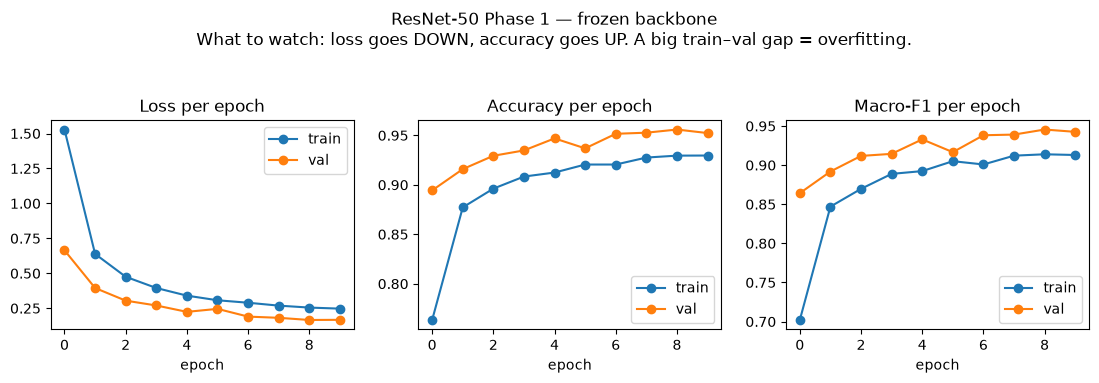

In [31]:
# PHASE 1 — FREEZE BACKBONE OF RESNET-50 AND TRAIN ONLY THE NEW HEAD
resnet50_model = build_model(backbone="resnet50", n_classes=NUM_CLASSES, pretrained=True, freeze_backbone=True, dropout=0.3).to(device)
phase1_criterion = nn.CrossEntropyLoss(weight=class_weights)
# # Only pass trainable parameters to the optimizer
# phase1_optimizer = torch.optim.Adam(filter(lambda parameter: parameter.requires_grad,resnet50_model.parameters()),lr=1e-3,weight_decay=1e-4)
resnet50_optimizer = torch.optim.Adam(resnet50_model.fc.parameters(), lr=1e-3)


PHASE1_EPOCHS = 10
PHASE1_PATIENCE = 3

phase1_start = time.time()

(
    resnet50_history,
    resnet50_best_epoch,
    resnet50_best_state,
    resnet50_best_macro_f1
) = train_model(model=resnet50_model,train_loader=train_loader,val_loader=val_loader,crit=phase1_criterion,opt=resnet50_optimizer,
    epochs=PHASE1_EPOCHS,patience=PHASE1_PATIENCE)

phase1_seconds = time.time() - phase1_start

resnet50_model.load_state_dict(resnet50_best_state)

print("Phase 1 best epoch:", resnet50_best_epoch)
print("Phase 1 best validation macro-F1:",f"{resnet50_best_macro_f1:.4f}")
print("Phase 1 duration:",f"{phase1_seconds / 60:.2f} minutes")

plot_history(resnet50_history,title="ResNet-50 Phase 1 — frozen backbone")

epoch  1/10 | train loss 1.583 acc 0.653 macro-F1 0.569 | val loss 0.479 acc 0.895 macro-F1 0.865
epoch  2/10 | train loss 0.749 acc 0.803 macro-F1 0.755 | val loss 0.342 acc 0.916 macro-F1 0.897
epoch  3/10 | train loss 0.628 acc 0.822 macro-F1 0.781 | val loss 0.297 acc 0.918 macro-F1 0.891
epoch  4/10 | train loss 0.582 acc 0.826 macro-F1 0.786 | val loss 0.282 acc 0.917 macro-F1 0.901
epoch  5/10 | train loss 0.555 acc 0.831 macro-F1 0.794 | val loss 0.258 acc 0.923 macro-F1 0.908
epoch  6/10 | train loss 0.543 acc 0.834 macro-F1 0.799 | val loss 0.241 acc 0.927 macro-F1 0.913
epoch  7/10 | train loss 0.519 acc 0.835 macro-F1 0.803 | val loss 0.229 acc 0.931 macro-F1 0.919
epoch  8/10 | train loss 0.516 acc 0.838 macro-F1 0.802 | val loss 0.246 acc 0.924 macro-F1 0.909
epoch  9/10 | train loss 0.515 acc 0.840 macro-F1 0.808 | val loss 0.222 acc 0.928 macro-F1 0.914
epoch 10/10 | train loss 0.492 acc 0.845 macro-F1 0.815 | val loss 0.223 acc 0.927 macro-F1 0.907
Early stopping at ep

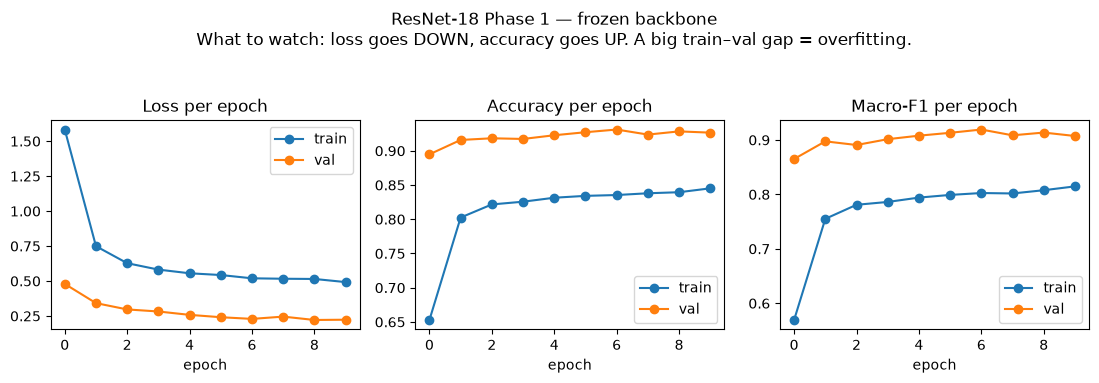

In [32]:
# RESNET-18 — PHASE 1 WITH FROZEN PRETRAINED BACKBONE

resnet18_model = build_model(backbone="resnet18", n_classes=NUM_CLASSES, pretrained=True, freeze_backbone=True, dropout=0.3).to(device)
resnet18_optimizer = torch.optim.Adam(resnet18_model.fc.parameters(), lr=1e-3)


RESNET18_EPOCHS = 10
RESNET18_PATIENCE = 3

resnet18_start = time.time()

(
    resnet18_history,
    resnet18_best_epoch,
    resnet18_best_state,
    resnet18_best_macro_f1
) = train_model(model=resnet18_model, train_loader=train_loader, val_loader=val_loader, crit=phase1_criterion,opt=resnet18_optimizer,
    epochs=RESNET18_EPOCHS,patience=RESNET18_PATIENCE)

resnet18_seconds = time.time() - resnet18_start
resnet18_model.load_state_dict(resnet18_best_state)

print("ResNet-18 best epoch:", resnet18_best_epoch)
print("ResNet-18 best validation Macro-F1:", f"{resnet18_best_macro_f1:.4f}")
print("ResNet-18 training time:", f"{resnet18_seconds / 60:.2f} minutes")

plot_history(resnet18_history, title="ResNet-18 Phase 1 — frozen backbone")

In [33]:
# compare the best validation macro-F1 scores of SimpleCNN, ResNet-18, and ResNet-50

comparison = pd.DataFrame({
    "model":            ["SimpleCNN (baseline)", "ResNet-18", "ResNet-50"],
    "pretrained":       ["no", "yes", "yes"],
    "total_params":     [f"{p/1e6:.1f}M" for p in total_parameters],
    "trainable_frozen": [f"{t:,}" for t in trainable_parameters],
    "input":            ["224²", "224²", "224²"],
    "role":             ["floor / sanity", "light variant", "final model"],
    "val_macro_F1":     [best_val_macro_f1, resnet18_best_macro_f1, resnet50_best_macro_f1],   # <-- you fill these in
})

display(comparison)

,model,pretrained,total_params,trainable_frozen,input,role,val_macro_F1
0,SimpleCNN (baseline),no,0.2M,"246,438",224²,floor / sanity,0.962068
1,ResNet-18,yes,11.2M,"19,494",224²,light variant,0.919177
2,ResNet-50,yes,23.6M,"77,862",224²,final model,0.945548


epoch  1/10 | train loss 0.129 acc 0.961 macro-F1 0.951 | val loss 0.051 acc 0.985 macro-F1 0.980
epoch  2/10 | train loss 0.054 acc 0.983 macro-F1 0.979 | val loss 0.031 acc 0.990 macro-F1 0.987
epoch  3/10 | train loss 0.046 acc 0.986 macro-F1 0.981 | val loss 0.029 acc 0.991 macro-F1 0.988
epoch  4/10 | train loss 0.040 acc 0.988 macro-F1 0.983 | val loss 0.029 acc 0.990 macro-F1 0.987
epoch  5/10 | train loss 0.028 acc 0.991 macro-F1 0.989 | val loss 0.032 acc 0.990 macro-F1 0.988
epoch  6/10 | train loss 0.033 acc 0.991 macro-F1 0.989 | val loss 0.025 acc 0.993 macro-F1 0.991
epoch  7/10 | train loss 0.033 acc 0.992 macro-F1 0.989 | val loss 0.032 acc 0.989 macro-F1 0.982
epoch  8/10 | train loss 0.016 acc 0.994 macro-F1 0.993 | val loss 0.020 acc 0.994 macro-F1 0.991
epoch  9/10 | train loss 0.021 acc 0.995 macro-F1 0.993 | val loss 0.031 acc 0.990 macro-F1 0.987
epoch 10/10 | train loss 0.023 acc 0.993 macro-F1 0.991 | val loss 0.019 acc 0.994 macro-F1 0.993
Phase 2 best epoch: 

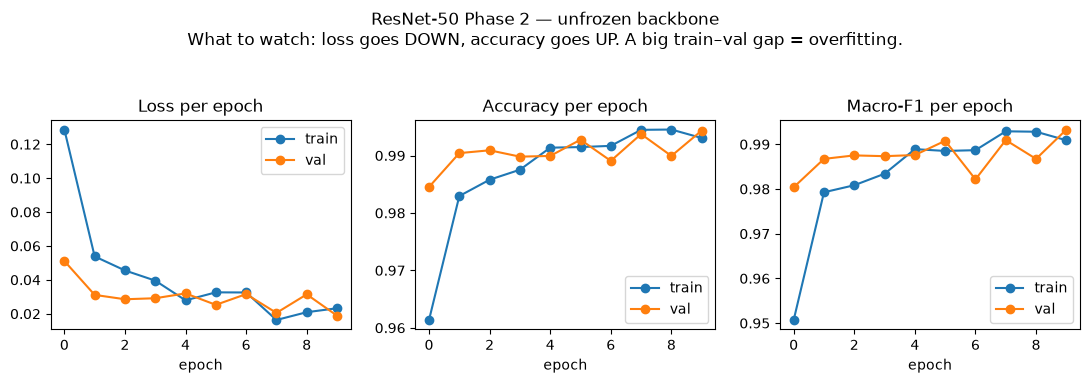

In [35]:
#Phase 2 — UNFREEZE BACKBONE OF RESNET-50 AND FINE-TUNE ENTIRE MODEL

for p in resnet50_model.parameters():
    p.requires_grad = True

phase2_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet50_model.parameters()), lr=1e-4)

PHASE2_EPOCHS = 10
PHASE2_PATIENCE = 3

phase2_start = time.time()

(
    resnet50_phase2_history,
    resnet50_phase2_best_epoch,
    resnet50_phase2_best_state,
    resnet50_phase2_best_macro_f1
) = train_model(model=resnet50_model,train_loader=train_loader,val_loader=val_loader,crit=phase1_criterion,opt=phase2_optimizer,
    epochs=PHASE2_EPOCHS,patience=PHASE2_PATIENCE)

resnet50_phase2_seconds = time.time() - phase2_start

resnet50_model.load_state_dict(resnet50_phase2_best_state)

print("Phase 2 best epoch:", resnet50_phase2_best_epoch)
print("Phase 2 best validation macro-F1:",f"{resnet50_phase2_best_macro_f1:.4f}")
print("Phase 2 duration:",f"{resnet50_phase2_seconds / 60:.2f} minutes")

plot_history(resnet50_phase2_history,title="ResNet-50 Phase 2 — unfrozen backbone")

epoch  1/10 | train loss 0.294 acc 0.906 macro-F1 0.879 | val loss 0.112 acc 0.965 macro-F1 0.952
epoch  2/10 | train loss 0.146 acc 0.954 macro-F1 0.941 | val loss 0.069 acc 0.978 macro-F1 0.970
epoch  3/10 | train loss 0.100 acc 0.967 macro-F1 0.956 | val loss 0.073 acc 0.977 macro-F1 0.970
epoch  4/10 | train loss 0.086 acc 0.972 macro-F1 0.965 | val loss 0.051 acc 0.983 macro-F1 0.980
epoch  5/10 | train loss 0.067 acc 0.977 macro-F1 0.970 | val loss 0.060 acc 0.982 macro-F1 0.974
epoch  6/10 | train loss 0.060 acc 0.981 macro-F1 0.976 | val loss 0.052 acc 0.986 macro-F1 0.982
epoch  7/10 | train loss 0.051 acc 0.985 macro-F1 0.980 | val loss 0.055 acc 0.983 macro-F1 0.974
epoch  8/10 | train loss 0.055 acc 0.982 macro-F1 0.975 | val loss 0.047 acc 0.986 macro-F1 0.980
epoch  9/10 | train loss 0.052 acc 0.983 macro-F1 0.978 | val loss 0.032 acc 0.990 macro-F1 0.986
epoch 10/10 | train loss 0.041 acc 0.986 macro-F1 0.983 | val loss 0.033 acc 0.990 macro-F1 0.988
ResNet-18 Phase 2 be

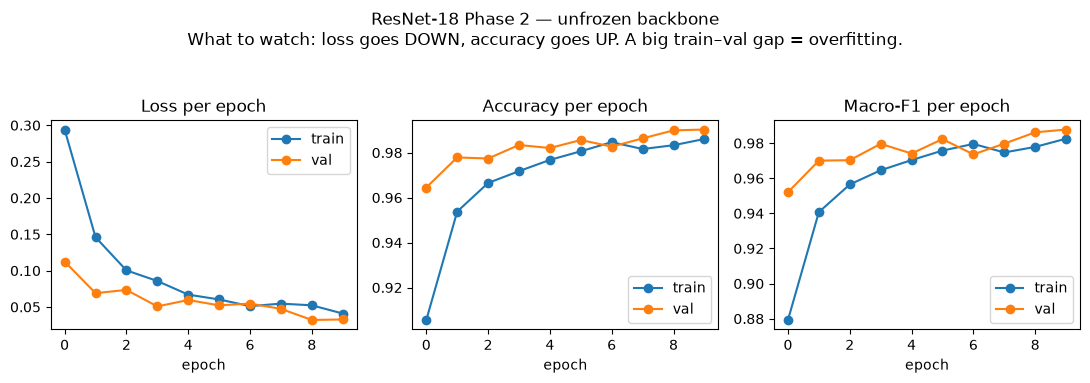

In [36]:
# RESNET-18 PHASE 2 — FINE-TUNE LAYER 4

# Unfreeze the final residual block
for p in resnet18_model.layer4.parameters():
    p.requires_grad = True

# Phase 2 optimizer — 10x smaller learning rate
resnet18_phase2_optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad,resnet18_model.parameters()),lr=1e-4)

RESNET18_PHASE2_EPOCHS = 10
RESNET18_PHASE2_PATIENCE = 3

resnet18_phase2_start = time.time()

(
    resnet18_phase2_history,
    resnet18_phase2_best_epoch,
    resnet18_phase2_best_state,
    resnet18_phase2_best_macro_f1
) = train_model(model=resnet18_model,train_loader=train_loader,val_loader=val_loader,crit=phase1_criterion,opt=resnet18_phase2_optimizer,
    epochs=RESNET18_PHASE2_EPOCHS,patience=RESNET18_PHASE2_PATIENCE)

resnet18_phase2_seconds = time.time() - resnet18_phase2_start

# Restore best Phase 2 weights
resnet18_model.load_state_dict(resnet18_phase2_best_state)

print("ResNet-18 Phase 2 best epoch:",resnet18_phase2_best_epoch)
print("ResNet-18 Phase 2 best validation Macro-F1:",f"{resnet18_phase2_best_macro_f1:.4f}")
print("ResNet-18 Phase 2 training time:",f"{resnet18_phase2_seconds / 60:.2f} minutes")
plot_history(resnet18_phase2_history,title="ResNet-18 Phase 2 — unfrozen backbone")

In [37]:
comparison_finetuned = pd.DataFrame({
    "Model": ["ResNet-18", "ResNet-50"],
    "Unfrozen Layers": ["layer4 + fc", "layer4 + fc"],
    "Validation Macro-F1": [
        resnet18_phase2_best_macro_f1,
        resnet50_phase2_best_macro_f1
    ],
    "Best Epoch": [
        resnet18_phase2_best_epoch,
        resnet50_phase2_best_epoch
    ],
    "Training Time (min)": [
        round(resnet18_phase2_seconds / 60, 2),
        round(resnet50_phase2_seconds / 60, 2)
    ]
})

display(comparison_finetuned)

,Model,Unfrozen Layers,Validation Macro-F1,Best Epoch,Training Time (min)
0,ResNet-18,layer4 + fc,0.987763,10,23.95
1,ResNet-50,layer4 + fc,0.993300,10,46.74
